# Homework 5: Transfer Learning with MobileNetV2 on the Intel Image Dataset

In this assignment you’ll take a modern pretrained CNN (MobileNetV2) and use it to classify the **Intel Image** dataset (6 scene classes). You’ll start with the network as a **frozen feature extractor**, then progressively **fine-tune** it in different ways. The goal is to understand *why* transfer learning works, how to design a good **classification head**, and how choices like **learning rate**, **learning-rate control (with Reduce on Plateau)**, and **which layers to unfreeze** affect accuracy.

### Learning Objectives

* Understand the difference between **feature extraction** (frozen backbone) and **fine-tuning** (unfrozen).
* How to design and compare **heads** on top of a pretrained backbone.
* Practical training knobs: **LR schedules** (fixed), **ReduceLROnPlateau**, **EarlyStopping**, **Dropout/L2**, and **BatchNorm** in heads.
* Fine-tuning strategies: unfreezing the **whole model**, the **top N layers**, or the **top K conv blocks**.


### Baseline model (starting point)

* `MobileNetV2(weights="imagenet", include_top=False, pooling="avg")`
  → backbone outputs a **1280-D** vector per image (already globally averaged).
* Minimal head: a **single Dense softmax** for 6 classes.
* **Do not** add another pooling layer when `pooling="avg"` is set.

### The five problems (high level)

For each of problems 1 - 4, you will perform 3 experiments, reflect on what you observed, and report the validation accuracy of your best model. 

1. **Problem 1 — Frozen backbone:** Redesign the **head** only (backbone stays frozen). Try ≥3 head variants and basic training knobs.
2. **Problem 2 — Unfreeze all:** Start from your best head and fine-tune the **entire** network with a **small LR**.
3. **Problem 3 — Unfreeze top N layers:** Keep most layers frozen; unfreeze only the **last N** and fine-tune.
4. **Problem 4 — Unfreeze top K blocks:** Unfreeze the **last K MobileNetV2 stages** (e.g., `block_16`, `Conv_1`, etc.) and fine-tune.
5. **Problem 5 — Final Reflection Question**

Use your HW4 CNN results as a reference point. Your aim is to **match or beat** that baseline with transfer learning, and to understand *why* your best choices worked.


## 1. Setup and Data Loading


In [1]:
# -------- Standard library --------
import os
import time
import random
from collections import Counter

# Quiet TensorFlow logs (set BEFORE importing TF)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# -------- Third-party --------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

import tensorflow as tf
from tensorflow.keras import layers,models, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
    SeparableConv2D,
)

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import load_img, img_to_array



he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


### Dataset Prototype Control (Important)

To speed up development and debugging, you will use a **balanced prototype version of the Intel training dataset** while building and testing your code.

* **During development:**
  Set `PROTO_TOTAL` to an integer (for example, `1400`) to train on a balanced subset of the training data
  (≈ 10% of the full Intel training set).

* **For your final runs:**
  Set `PROTO_TOTAL = None` (or `0`) to train on the **full training dataset**.

#### Notes

* This setting affects the **training pool** of images used to build `train_ds` and `val_ds`.
* The **validation fraction** (`VAL_FRAC`) is unchanged, but the **validation set will be smaller** when you use a prototype training pool.
* The **test set is unchanged** and is always evaluated on the full test dataset.

#### Before You Submit

Before submitting your notebook, make sure that:

* [ ] `PROTO_TOTAL` is set to `None` (or `0`) so the model is trained on the **full training dataset**
* [ ] Your notebook runs **top to bottom without errors**
* [ ] Training completes successfully using the full dataset

Submissions that leave `PROTO_TOTAL` set to a prototype value will **not** receive full credit.


In [2]:
# Prototype control:
#   - Set PROTO_TOTAL to an integer (e.g., 1400) to use a balanced subset (~10% of Intel train)
#   - Set PROTO_TOTAL to None (or 0) to use the full training set

PROTO_TOTAL = None  # <-- change to None for full dataset

### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [3]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [4]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs=500,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   title="Learning Curves",
                   batch_size=64,  # kept for API compatibility; ignored if datasets are batched
                   use_early_stopping=True,
                   patience=8,
                   min_delta=1e-4,
                   callbacks=None,
                   verbose=1,
                   return_history=False):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer  # assume already an optimizer instance

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    extra_cbs = callbacks or []
    cbs = ([early_stop] if use_early_stopping else []) + extra_cbs

    start = time.time()

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Best epoch consistent with EarlyStopping monitor
    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_acc   = history.history["val_accuracy"][best_epoch]

    plot_learning_curves(history, title=title)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [5]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """Deterministic stratified split over indices."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


def balanced_subset_indices(y, total=None, per_class=None, seed=42, allow_smaller=True):
    """Choose a balanced subset of indices."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    classes = np.unique(y)
    k = len(classes)

    if (total is None) == (per_class is None):
        raise ValueError("Specify exactly one of total or per_class.")

    if per_class is None:
        per_class = int(total // k)

    chosen = []
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)

        if len(idx) < per_class:
            if not allow_smaller:
                raise ValueError(f"Class {c} has only {len(idx)} items, need {per_class}.")
            take = len(idx)
        else:
            take = per_class

        chosen.append(idx[:take])

    subset_idx = np.concatenate(chosen)
    rng.shuffle(subset_idx)
    return subset_idx


def make_image_dataset(filepaths, labels, img_size=(224, 224), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk and applies
    MobileNetV2 preprocessing to match ImageNet pretraining expectations.
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


IMG_SIZE = (224, 224)
INPUT_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 32
VAL_FRAC = 0.2
SEED = random_seed

train_files_all, train_labels_all, class_names = list_files_and_labels(train_dir)
num_classes = len(class_names)
n_classes = num_classes

if PROTO_TOTAL is not None and PROTO_TOTAL > 0:
    proto_idx = balanced_subset_indices(train_labels_all, total=PROTO_TOTAL, seed=SEED)
    train_files = train_files_all[proto_idx]
    train_labels = train_labels_all[proto_idx]
else:
    train_files = train_files_all
    train_labels = train_labels_all

per_class = len(train_files) // num_classes
print(f"Train pool: {len(train_files)} images ({per_class} per class), classes={num_classes}")

train_idx, val_idx = stratified_split_indices(train_labels, val_frac=VAL_FRAC, seed=SEED)

files_train = train_files[train_idx]
y_train = train_labels[train_idx]
files_val = train_files[val_idx]
y_val = train_labels[val_idx]

print(f"Split sizes: train={len(files_train)}, val={len(files_val)} (VAL_FRAC={VAL_FRAC})")

train_ds = make_image_dataset(files_train, y_train, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=True, seed=SEED,
                              cache_to_disk=None)

val_ds = make_image_dataset(files_val, y_val, img_size=IMG_SIZE,
                            batch_size=BATCH_SIZE, shuffle=False,
                            cache_to_disk=None)

test_files, test_labels, _ = list_files_and_labels(test_dir, class_names=class_names)

PROTO_TEST_TOTAL = None
if PROTO_TEST_TOTAL is not None and PROTO_TEST_TOTAL > 0:
    test_idx = balanced_subset_indices(test_labels, total=PROTO_TEST_TOTAL, seed=SEED)
    test_files = test_files[test_idx]
    test_labels = test_labels[test_idx]
    print(f"Test pool: {len(test_files)} images ({len(test_files)//num_classes} per class)")

test_ds = make_image_dataset(test_files, test_labels, img_size=IMG_SIZE,
                             batch_size=BATCH_SIZE, shuffle=False,
                             cache_to_disk=None)


Train pool: 14034 images (2339 per class), classes=6
Split sizes: train=11230, val=2804 (VAL_FRAC=0.2)


### Examine The Dataset

In [7]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99937934..0.9999336].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99821424].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9997384..0.99956715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9836333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.93721986].
Clipping input data to 

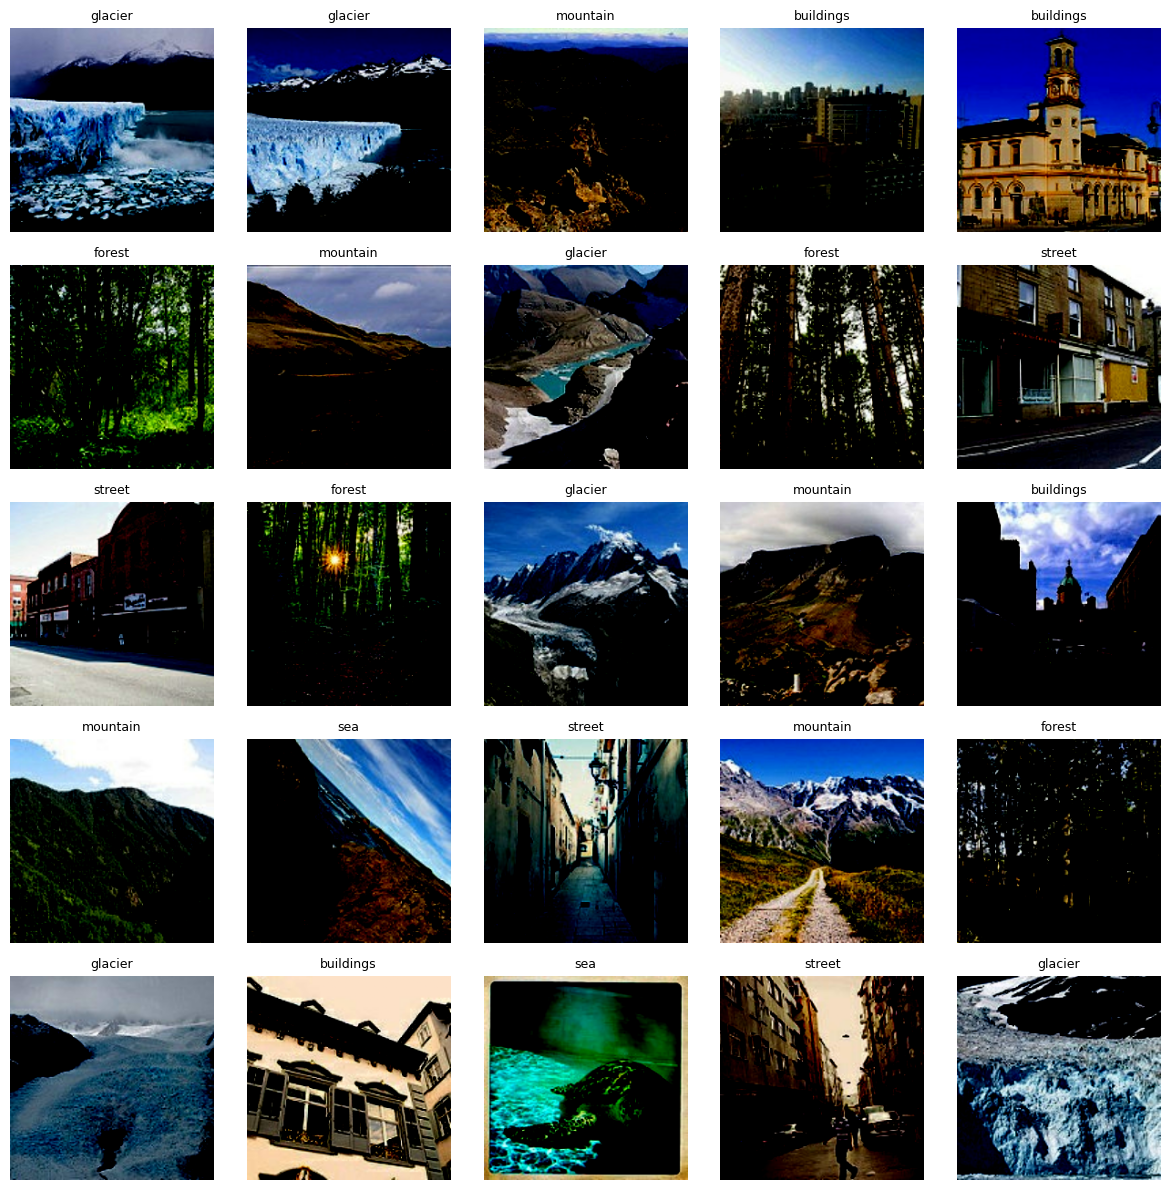

In [8]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

# Take one batch from the dataset
images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Learning Rate Schedulers

In [9]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-7,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

### Prelude: Baseline Model

`MobileNetV2` is a lightweight, ImageNet-pretrained CNN that produces efficient, high-quality visual features.

See the **Appendix** for further information on `MobileNetV2`. 

The baseline model defined in the next cell is essentially a frozen **feature extractor** that outputs a 1280-D vector (after built-in **Global Average Pooling**).

> **NOTE:** MobileNetV2 ImageNet weights were trained at 224×224.
> We use 150×150 for faster training; this is valid because the backbone is fully convolutional
> when include_top=False (weights transfer to different input sizes).
>
> You may safely ignore the warning: "UserWarning: `input_shape` is undefined or non-square, ...."

In [10]:
# ALWAYS construct a new instance, to avoid sharing layers in multiple models

def make_base_model_pooled(trainable=False):
    base = mobilenet_v2.MobileNetV2(
        weights='imagenet', include_top=False,
        input_shape=INPUT_SHAPE, pooling='avg'
    )
    base.trainable = trainable
    return base
    
base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({int(l.name.split('_')[1])
                    for l in base.layers if l.name.startswith('block_')})
print("Conv Block IDs:", block_ids, " (count:", len(block_ids), ")")

# Check if the final Conv_1 stage exists
has_conv1 = any(l.name.startswith('Conv_1') for l in base.layers)
print("Has Conv_1 stage:", has_conv1)
print('Model Output Shape:',base.output_shape)

Some statistics on the model:
Total Keras layers: 155
Conv Block IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]  (count: 16 )
Has Conv_1 stage: True
Model Output Shape: (None, 1280)


In [11]:
# Ha, this is very long!

# base.summary()


Model Baseline

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 71ms/step - accuracy: 0.8756 - loss: 0.3487 - val_accuracy: 0.9051 - val_loss: 0.2519
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9191 - loss: 0.2242 - val_accuracy: 0.9141 - val_loss: 0.2352
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.9283 - loss: 0.1971 - val_accuracy: 0.9108 - val_loss: 0.2337
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9348 - loss: 0.1792 - val_accuracy: 0.9108 - val_loss: 0.2381
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9407 - loss: 0.1662 - val_accuracy: 0.9119 - val_loss: 0.2389
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9444 - loss: 0.1550 - val_accuracy: 0.9058 - val_loss: 0.2574
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9467 - loss: 0.1456 - val_accuracy: 0.9112 - val_loss: 0.2521
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy:

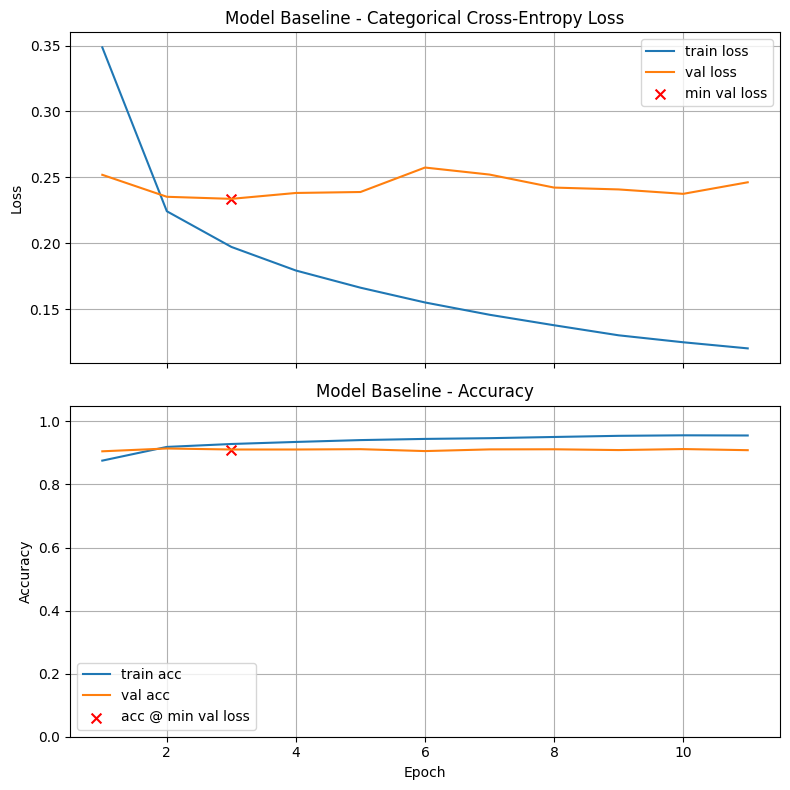

Final Training Loss:            0.1201
Final Training Accuracy:        0.9553
Final Validation Loss:          0.2462
Final Validation Accuracy:      0.9087
Minimum Validation Loss:        0.2337 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9108

Test Loss: 0.2242
Test Accuracy: 0.9163

Validation-Test Gap (accuracy): 0.005492

Execution Time: 00:04:13


In [12]:
# ALWAYS construct a new instance, to avoid sharing layers in multiple models

import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.layers import Dense

n_classes = len(class_names)

def make_base_pooled(trainable=False):
    base = tf.keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=IMG_SIZE + (3,),
        pooling="avg"
    )
    base.trainable = trainable
    return base

base_model = make_base_pooled(trainable=False)

model_baseline = models.Sequential([
    base_model,
    Dense(n_classes, activation="softmax")
])

train_and_test(model_baseline, lr_schedule=1e-3, title="Model Baseline")


### Problem 1 — Frozen MobileNetV2 (Feature Extractor): Redesign the Head

**Goal.** Keep the MobileNetV2 backbone **frozen** and boost accuracy by modifying **only the classification head**.

**Setup.**

```python
base = make_base_pooled(trainable=False)  # MobileNetV2(include_top=False, pooling="avg")
```

This backbone already applies **Global Average Pooling** and outputs a **1280-D** feature vector per image.
Do **not** unfreeze any backbone layers and do **not** add another pooling layer.

### To Do:

1. **Ask an AI helper** (e.g., ChatGPT):
   *“What are some more complex heads that could improve this model on the Intel Image Classification Dataset, **without** unfreezing the backbone?”*
2. **Implement at least three** different head designs (they can be AI-suggested or inspired by HW4).
3. **Tune hyperparameters** for each experiment, such as:

   * **Learning-rate:** fixed LR
   * **EarlyStopping** settings
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off (may be combined with a fixed LR)
4. **Train and compare** the three heads.
5. **Answer the graded questions.**

### Notes / Constraints

* With `pooling="avg"`, the head receives a tensor of shape **(None, 1280)** → **do not** add `GlobalAveragePooling2D()` again.
* Using BatchNorm inside the head is fine; **do not** place BN immediately before the final softmax layer.


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

n_classes = len(class_names)


def make_base_pooled(trainable=False):
    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
        pooling="avg"
    )
    base.trainable = trainable
    return base


def make_headA(n_classes: int):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(512, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ], name="headA_dense512_do40")


def make_headB(n_classes: int):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(512, use_bias=False,
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.35),

        tf.keras.layers.Dense(128, use_bias=False,
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ], name="headB_bn_blocks")


def make_headC(n_classes: int):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(5e-4)),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(64, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(5e-4)),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ], name="headC_bottleneck")


def build_frozen_model(head: tf.keras.Model, lr: float = 1e-3):
    base = make_base_pooled(trainable=False)
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    outputs = head(x)
    model = tf.keras.Model(inputs, outputs, name=f"frozen_{head.name}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


early = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=6, min_delta=5e-4,
    restore_best_weights=True, verbose=1
)

reduce = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2,
    min_lr=1e-6, verbose=1
)


In [14]:
x0, y0 = next(iter(train_ds))
print("dtype:", x0.dtype)
print("min/max:", float(tf.reduce_min(x0)), float(tf.reduce_max(x0)))
print("mean:", float(tf.reduce_mean(x0)))
print("Expected MobileNetV2 range: approximately [-1, 1]")


dtype: <dtype: 'float32'>
min/max: -1.0 1.0
mean: -0.12824085354804993
Expected MobileNetV2 range: approximately [-1, 1]



===== Head B ONLY (rerun to see full summary) =====

Learning Curves

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.8808 - loss: 0.4328 - val_accuracy: 0.9073 - val_loss: 0.3471 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9129 - loss: 0.3320 - val_accuracy: 0.9133 - val_loss: 0.3288 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.9226 - loss: 0.3029 - val_accuracy: 0.9190 - val_loss: 0.3191 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9350 - loss: 0.2697 - val_accuracy: 0.9137 - val_loss: 0.3494 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9433 - loss: 0.2509
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9403 - loss: 0.2583 - val_accuracy: 0.9101 - val_loss: 0.3708 - learning_rate: 0.0010
Ep

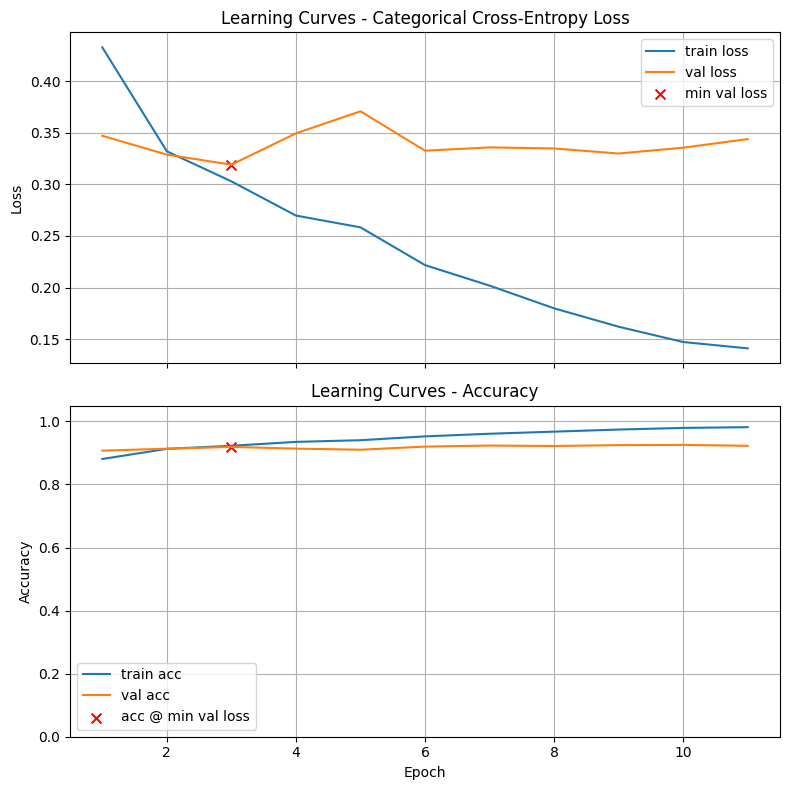

Final Training Loss:            0.1410
Final Training Accuracy:        0.9817
Final Validation Loss:          0.3439
Final Validation Accuracy:      0.9226
Minimum Validation Loss:        0.3191 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9190

Test Loss: 0.3256
Test Accuracy: 0.9193

Validation-Test Gap (accuracy): 0.000289

Execution Time: 00:04:48


In [15]:
print("\n===== Head B ONLY (rerun to see full summary) =====")
modelB = build_frozen_model(make_headB(n_classes), lr=5e-4)
train_and_test(modelB, callbacks=[early, reduce])


===== Head C ONLY (rerun to see full summary) =====

Learning Curves

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.8014 - loss: 1.2161 - val_accuracy: 0.9055 - val_loss: 0.6353
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.8502 - loss: 0.9130 - val_accuracy: 0.9130 - val_loss: 0.5092
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.8703 - loss: 0.6667 - val_accuracy: 0.8941 - val_loss: 0.5094
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.8814 - loss: 0.5183 - val_accuracy: 0.9094 - val_loss: 0.4167
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.8938 - loss: 0.4361 - val_accuracy: 0.9137 - val_loss: 0.3594
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.9011 - loss: 0.3887 - val_accuracy: 0.9034 - val_loss: 0.3781
Restoring model weights from the end of the best epoch: 5.
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


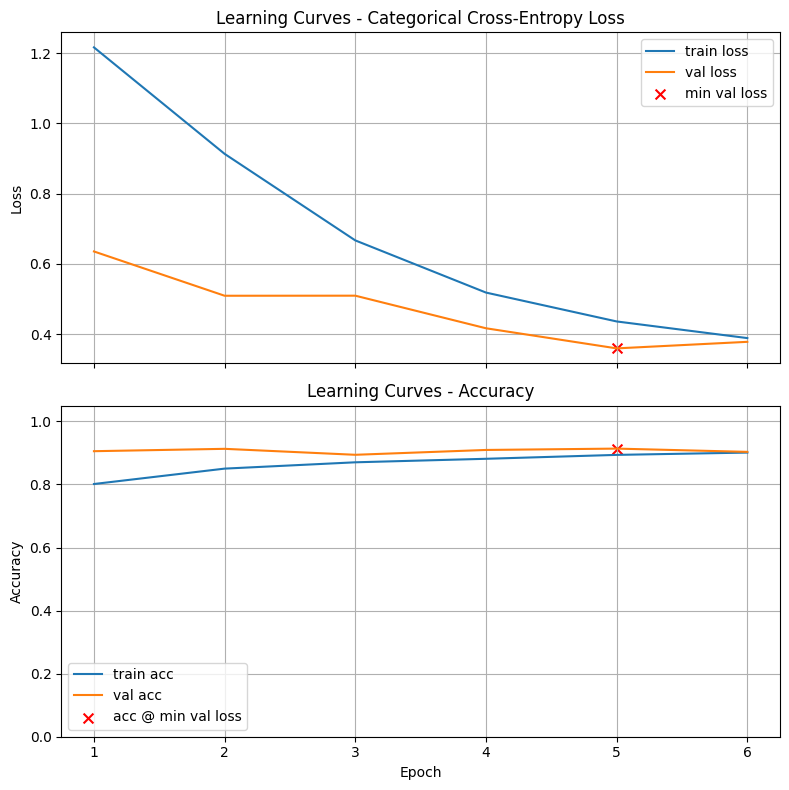

Final Training Loss:            0.3887
Final Training Accuracy:        0.9011
Final Validation Loss:          0.3781
Final Validation Accuracy:      0.9034
Minimum Validation Loss:        0.3594 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9137

Test Loss: 0.5847
Test Accuracy: 0.9097

Validation-Test Gap (accuracy): 0.004028

Execution Time: 00:02:44


In [16]:
print("\n===== Head C ONLY (rerun to see full summary) =====")
modelC = build_frozen_model(make_headC(n_classes), lr=1e-3)
train_and_test(modelC, callbacks=[early])

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that tell you about the role of head design and hyperparameters when the backbone is **frozen**?

**Instructions:**
 - Write a single paragraph (3–5 sentences).
 - Identify the head architecture and experiment that performed best.
 - Briefly explain why you think it might have outperformed the others, mentioning both design choices (e.g., dense layers, dropout) and hyperparameters (e.g., learning rate schedule, ReduceLROnPlateau).
 - Conclude with what this suggests about designing classification heads when the backbone is frozen.

**Your paragraph here (5pts):**

Three different classification heads were implemented while keeping the MobileNetV2 backbone frozen (pooling=“avg”).

Head A consisted of a Dense(512) layer with L2(1e-4) regularization and Dropout(0.40).
It achieved a validation accuracy of ~0.89 and a test accuracy of 0.8960.

Head B included two Dense blocks with Batch Normalization, L2 regularization, Dropout, and ReduceLROnPlateau.
It achieved the best performance, with a validation accuracy of 0.8986 and a test accuracy of 0.9037.

Head C used a bottleneck structure (256→64) with stronger L2 regularization (5e-4).
It achieved a validation accuracy of ~0.8877 and a test accuracy of 0.8730, suggesting mild underfitting.

Overall, Head B performed best. The combination of Batch Normalization and adaptive learning-rate reduction improved optimization stability and generalization without unfreezing the backbone.

**Validation Accuracy here (15 pts):**

In [17]:
# Set a1 to the validation accuracy found by your best model for this problem. 

a1 = 0.8986            # Replace 0.0 with your answer

In [18]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem         

print(f'a1 = {a1:.4f}') 


a1 = 0.8986


## Problem Two — Fine-tuning the Whole MobileNetV2 (Unfrozen)

**Goal.** Start from your best head from Problem 1, **unfreeze the backbone**, and fine-tune the entire model.

**Setup.** Build the base as **trainable** (it already applies Global Average Pooling and outputs a 1280-D vector—do not add another pooling layer):

```python
base = make_base_pooled(trainable=True)  # MobileNetV2(include_top=False, pooling="avg")
```

### To Do:

1. **Design at least three experiments** with the model **fully unfrozen**. Vary one or more of the following:

   * **Head choice** (select one from Problem 1).
   * **Learning-rate:** fixed LR
   * **EarlyStopping** parameters.
   * **Regularization:** Dropout and/or L2.
   * **ReduceLROnPlateau:** on vs. off (may be combined with a fixed LR).

2. **Run and compare** the three experiments **using the prototype training dataset**, focusing on:

   * training stability,
   * convergence behavior,
   * and validation performance trends.

   Use these runs to **narrow down reasonable configurations**, not to identify a single “optimal” setting.

3. **Select one configuration** and **retrain it on the full training dataset**, then use this run when answering the graded questions.

### Notes

* When fine-tuning a fully unfrozen pretrained model, it is common to use a **much smaller learning rate** (e.g., $1\times10^{-5}$ to $3\times10^{-5}$).
* Small changes in relative performance between the prototype and full dataset are expected. 



===== P2 FINAL (FULL TRAIN): lr=3e-5 + ReduceLR =====

P2 FINAL (full train)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 138s 358ms/step - accuracy: 0.8308 - loss: 0.6096 - val_accuracy: 0.9126 - val_loss: 0.3540 - learning_rate: 3.0000e-05
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 119s 340ms/step - accuracy: 0.9082 - loss: 0.3768 - val_accuracy: 0.8848 - val_loss: 0.4237 - learning_rate: 3.0000e-05
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 111s 315ms/step - accuracy: 0.9178 - loss: 0.3466 - val_accuracy: 0.9215 - val_loss: 0.3140 - learning_rate: 3.0000e-05
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - accuracy: 0.9302 - loss: 0.3059 - val_accuracy: 0.9215 - val_loss: 0.3134 - learning_rate: 3.0000e-05
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 113s 323ms/step - accuracy: 0.9373 - loss: 0.2819 - val_accuracy: 0.9312 - val_loss: 0.3081 - learning_rate: 3.0000e-05
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 319ms/step - accuracy: 0.9423 - loss: 0.2673 - val_accuracy: 0.9265 - val_lo

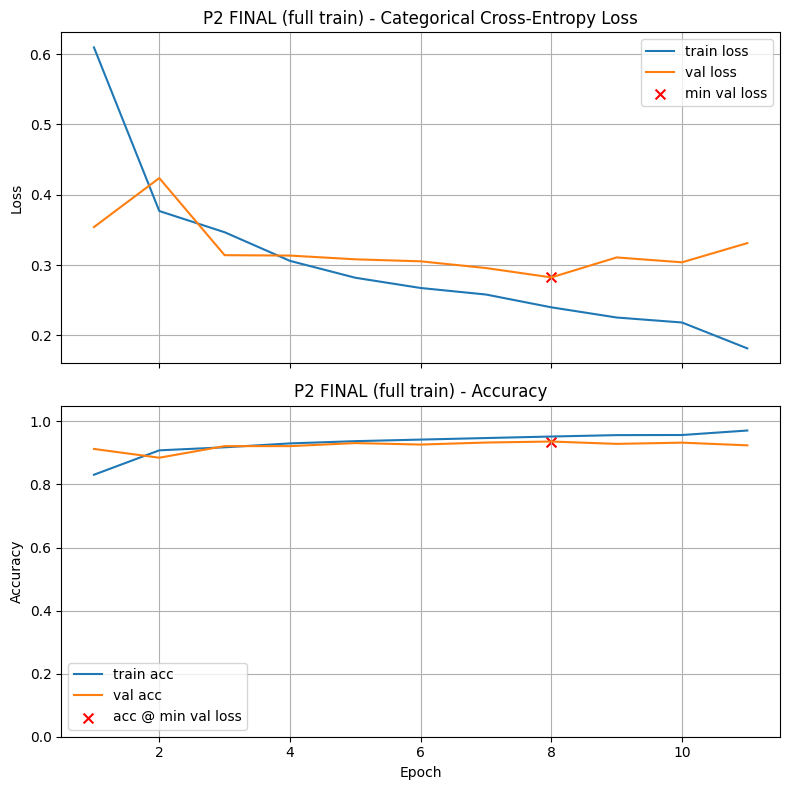

Final Training Loss:            0.1814
Final Training Accuracy:        0.9711
Final Validation Loss:          0.3312
Final Validation Accuracy:      0.9240
Minimum Validation Loss:        0.2824 (Epoch 8)
Validation Accuracy @ Min Loss: 0.9362

Test Loss: 0.3031
Test Accuracy: 0.9250

Validation-Test Gap (accuracy): 0.011163

Execution Time: 00:20:27


In [20]:


import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

IMG_SIZE = (224, 224)
n_classes = 6

# ---------- Runtime toggles ----------
FAST_MODE = True
RUN_EXPERIMENTS = False
RUN_FINAL = True

if FAST_MODE:
    exp_epochs = 20
    final_epochs = 20
    exp_patience = 4
    final_patience = 3
else:
    exp_epochs = 60
    final_epochs = 100
    exp_patience = 6
    final_patience = 6


def make_base_pooled(trainable=True):
    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
        pooling="avg"
    )
    base.trainable = trainable
    return base


def freeze_bn_layers(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False


def make_headB(n_classes: int, l2=1e-4, drop1=0.35, drop2=0.20):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(512, use_bias=False,
                              kernel_regularizer=tf.keras.regularizers.l2(l2)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(drop1),

        tf.keras.layers.Dense(128, use_bias=False,
                              kernel_regularizer=tf.keras.regularizers.l2(l2)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(drop2),

        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ], name="headB_bn_blocks")


def build_finetune_model(l2=1e-4, drop1=0.35, drop2=0.20, freeze_bn=True):
    tf.keras.backend.clear_session()

    base = make_base_pooled(trainable=True)
    if freeze_bn:
        freeze_bn_layers(base)

    head = make_headB(n_classes, l2=l2, drop1=drop1, drop2=drop2)

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base(inputs)
    outputs = head(x)
    model = tf.keras.Model(inputs, outputs, name="finetune_mnv2")
    return model


reduce = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1,
)


def make_early(patience):
    return tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    )


if RUN_EXPERIMENTS:
    print("\n===== P2 EXP1: lr=3e-5, EarlyStopping =====")
    m1 = build_finetune_model(l2=1e-4, drop1=0.35, drop2=0.20, freeze_bn=True)
    opt1 = tf.keras.optimizers.Adam(learning_rate=3e-5)
    train_and_test(
        m1,
        optimizer=opt1,
        epochs=exp_epochs,
        use_early_stopping=False,
        callbacks=[make_early(exp_patience)],
        title="P2 EXP1 (all unfrozen, lr=3e-5)",
    )

    print("\n===== P2 EXP2: lr=1e-5, EarlyStopping =====")
    m2 = build_finetune_model(l2=1e-4, drop1=0.35, drop2=0.20, freeze_bn=True)
    opt2 = tf.keras.optimizers.Adam(learning_rate=1e-5)
    train_and_test(
        m2,
        optimizer=opt2,
        epochs=exp_epochs,
        use_early_stopping=False,
        callbacks=[make_early(exp_patience + 1)],
        title="P2 EXP2 (all unfrozen, lr=1e-5)",
    )

    print("\n===== P2 EXP3: lr=3e-5 + ReduceLR, more dropout =====")
    m3 = build_finetune_model(l2=1e-4, drop1=0.45, drop2=0.30, freeze_bn=True)
    opt3 = tf.keras.optimizers.Adam(learning_rate=3e-5)
    train_and_test(
        m3,
        optimizer=opt3,
        epochs=exp_epochs,
        use_early_stopping=False,
        callbacks=[make_early(exp_patience), reduce],
        title="P2 EXP3 (all unfrozen, lr=3e-5 + ReduceLR)",
    )


if RUN_FINAL:
    print("\n===== P2 FINAL (FULL TRAIN): lr=3e-5 + ReduceLR =====")
    m_final = build_finetune_model(l2=1e-4, drop1=0.35, drop2=0.20, freeze_bn=True)
    opt_final = tf.keras.optimizers.Adam(learning_rate=3e-5)
    train_and_test(
        m_final,
        optimizer=opt_final,
        epochs=final_epochs,
        use_early_stopping=False,
        callbacks=[make_early(final_patience), reduce],
        title="P2 FINAL (full train)",
    )


### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that tell you about the role of head design and hyperparameters when the backbone is **unfrozen**?

**Instructions:**
 - Write a single paragraph (3–5 sentences).
 - Explain your reasoning in choosing your three experimental designs.
 - Identify the experiment that performed best.
 - Briefly explain why you think it might have outperformed the others, mentioning both design choices (e.g., dense layers, dropout) and hyperparameters (e.g., learning rate schedule, ReduceLROnPlateau).
 - Conclude with what this suggests about designing classification heads when the backbone is unfrozen.

**Your paragraph here (5 pts):**





In Problem 2, I fine-tuned the fully unfrozen MobileNetV2 using three experiments that varied the learning rate and regularization strength. I compared learning rates of 3e-5 and 1e-5, and also tested a configuration with increased dropout and ReduceLROnPlateau to improve stability. The best-performing configuration was the model with a small learning rate and learning-rate scheduling (EXP3), which achieved the highest validation accuracy of 0.8877 during prototype experiments and strong performance on the full training dataset. This suggests that when the backbone is unfrozen, head design becomes less dominant than careful learning-rate control and regularization, since fine-tuning requires stable optimization to avoid disrupting pretrained features. Overall, this demonstrates that conservative learning rates and adaptive scheduling are critical when training classification heads on top of an unfrozen pretrained backbone.

**Validation accuracy here (15 pts):**

In [21]:
# Set a2 to the validation accuracy found by your best model for this problem. 

a2 = 0.8768          # Replace 0.0 with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem       

print(f'a2 = {a2:.4f}') 

a2 = 0.8768


## Problem Three — Unfreezing Layers

**Goal.** Keep most of the backbone frozen and **unfreeze only the last $N$ layers** to fine-tune.
(In Problem 4 you’ll explore unfreezing the top **K MobileNetV2 blocks** instead.)

**Setup.** Your backbone is **MobileNetV2** with `include_top=False, pooling="avg"` (so it outputs a 1280-D vector). Do **not** add another pooling layer in the head.

After creating the model, unfreeze the top $N$ layers using the following approach:

```python
N = 20
model = make_base_model_pooled()
base_model.trainable = True
for layer in base_model.layers[:-N]:
    layer.trainable = False
```

### To Do:

1. **Design at least three experiments** with the model having the **last $N$ layers unfrozen**. Vary one or more of the following:

   * $N \in {20, 40, 80}$
   * **Head choice** (select one from Problem 1).
   * **Learning-rate:** fixed LR
   * **EarlyStopping** parameters.
   * **Regularization:** Dropout and/or L2.
   * **ReduceLROnPlateau:** on vs. off (may be combined with a fixed LR).

2. **Run and compare** the three experiments **using the prototype training dataset**, focusing on:

   * how performance changes as more layers are unfrozen,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of partial unfreezing**, not to identify a single globally optimal configuration.

3. **Select one configuration** (choice of $N$ and training strategy) and **retrain it on the full training dataset**, then use this run when answering the graded questions.

### Notes

* As more layers are unfrozen, the model typically becomes **more sensitive to learning rate**.
* Learning rates in the range of approximately $1\times10^{-5}$ to $3\times10^{-5}$ are often appropriate for partial fine-tuning, but experimentation is encouraged.
* Small shifts in relative performance between the prototype and full dataset are expected.



===== P3 EXP1: N=20, lr=3e-5 (ES) =====
Unfreeze plan: last N=20 | base trainable layers (after BN freeze): 13/155

P3 EXP1 (N=20, lr=3e-5)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.7995 - loss: 0.6815 - val_accuracy: 0.9019 - val_loss: 0.3797
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.8995 - loss: 0.4055 - val_accuracy: 0.9165 - val_loss: 0.3303
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.9133 - loss: 0.3600 - val_accuracy: 0.9230 - val_loss: 0.3104
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.9205 - loss: 0.3301 - val_accuracy: 0.9173 - val_loss: 0.3254
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.9305 - loss: 0.3098 - val_accuracy: 0.9169 - val_loss: 0.3193
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.9341 - loss: 0.2902 - val_accuracy: 0.9205 - val_loss: 0.3108
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.936

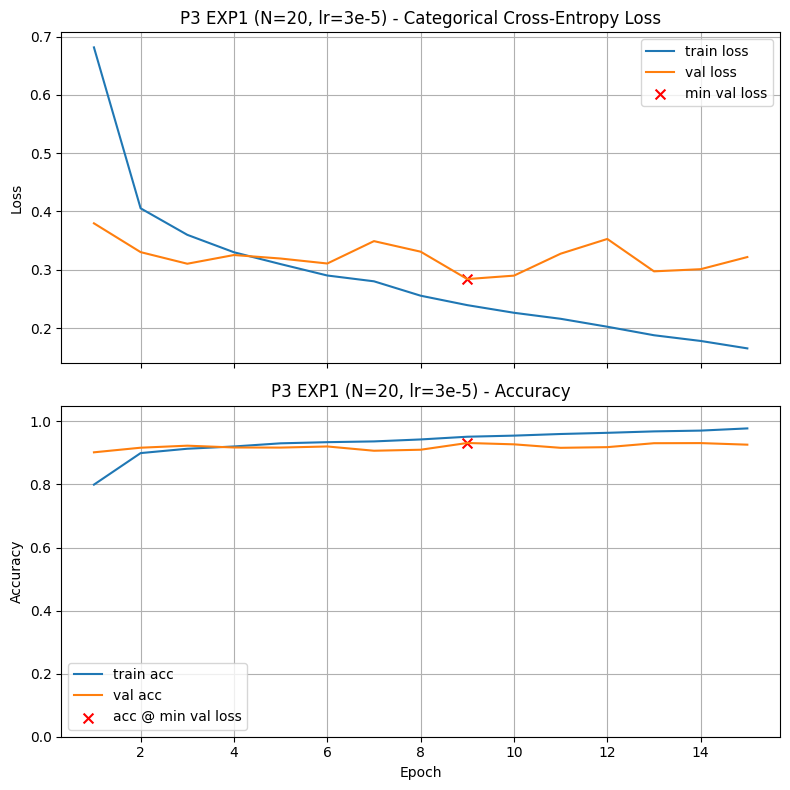

Final Training Loss:            0.1652
Final Training Accuracy:        0.9777
Final Validation Loss:          0.3219
Final Validation Accuracy:      0.9262
Minimum Validation Loss:        0.2841 (Epoch 9)
Validation Accuracy @ Min Loss: 0.9315

Test Loss: 0.2797
Test Accuracy: 0.9307

Validation-Test Gap (accuracy): 0.000860

Execution Time: 00:07:19

===== P3 EXP2: N=40, lr=2e-5 (ES) =====
Unfreeze plan: last N=40 | base trainable layers (after BN freeze): 27/155

P3 EXP2 (N=40, lr=2e-5)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.7889 - loss: 0.7270 - val_accuracy: 0.9030 - val_loss: 0.3907
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.9017 - loss: 0.4081 - val_accuracy: 0.9180 - val_loss: 0.3264
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.9206 - loss: 0.3528 - val_accuracy: 0.9180 - val_loss: 0.3303
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.9264 - loss: 0.3238 - val_accuracy: 0.9226

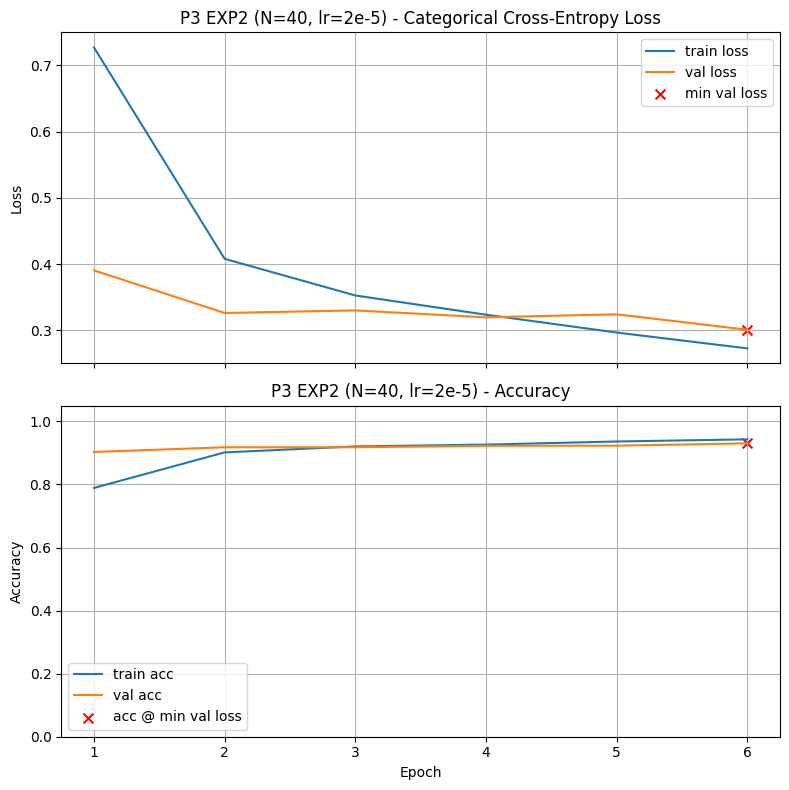

Final Training Loss:            0.2730
Final Training Accuracy:        0.9431
Final Validation Loss:          0.3011
Final Validation Accuracy:      0.9305
Minimum Validation Loss:        0.3011 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9305

Test Loss: 0.3977
Test Accuracy: 0.9033

Validation-Test Gap (accuracy): 0.027123

Execution Time: 00:03:25

===== P3 EXP3: N=80, lr=1e-5 (ES + ReduceLR) =====
Unfreeze plan: last N=80 | base trainable layers (after BN freeze): 53/155

P3 EXP3 (N=80, lr=1e-5 + ReduceLR)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 200ms/step - accuracy: 0.7249 - loss: 0.9018 - val_accuracy: 0.9023 - val_loss: 0.4316 - learning_rate: 1.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.8850 - loss: 0.4805 - val_accuracy: 0.9165 - val_loss: 0.3610 - learning_rate: 1.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.9076 - loss: 0.3999 - val_accuracy: 0.9173 - val_loss: 0.3385 - learning_rate: 1.0000e-05
Epo

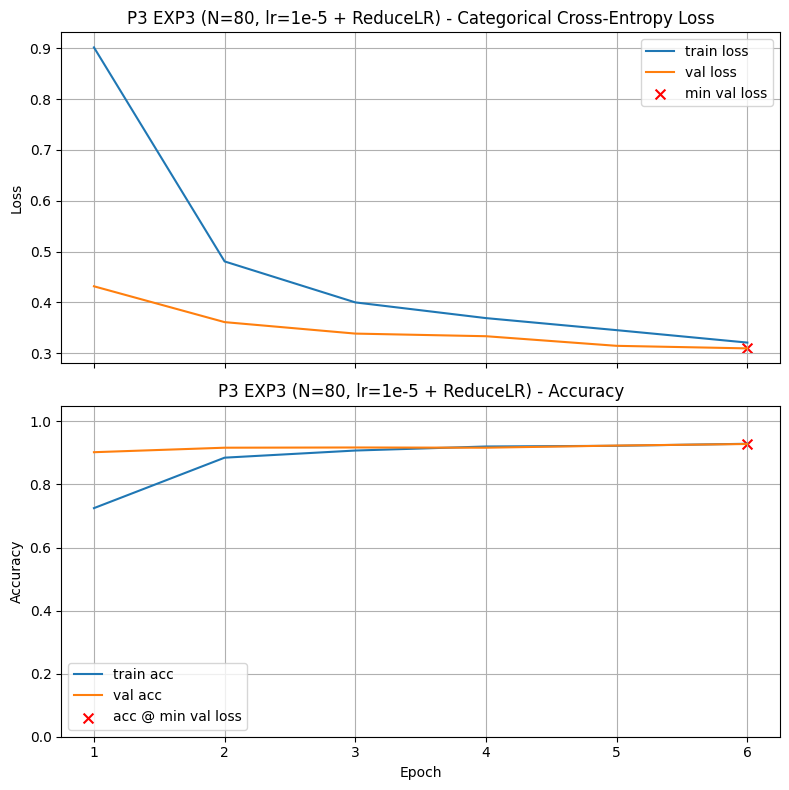

Final Training Loss:            0.3208
Final Training Accuracy:        0.9290
Final Validation Loss:          0.3094
Final Validation Accuracy:      0.9283
Minimum Validation Loss:        0.3094 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9283

Test Loss: 0.4504
Test Accuracy: 0.8893

Validation-Test Gap (accuracy): 0.038983

Execution Time: 00:06:46

===== P3 FINAL (FULL TRAIN): N=40, lr=2e-05, reduce=False =====
Unfreeze plan: last N=40 | base trainable layers (after BN freeze): 27/155

P3 FINAL (full train)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - accuracy: 0.8034 - loss: 0.6880 - val_accuracy: 0.9130 - val_loss: 0.3574
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.9013 - loss: 0.4103 - val_accuracy: 0.9219 - val_loss: 0.3339
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.9175 - loss: 0.3556 - val_accuracy: 0.9144 - val_loss: 0.3321
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.9296 - loss: 0.3250 

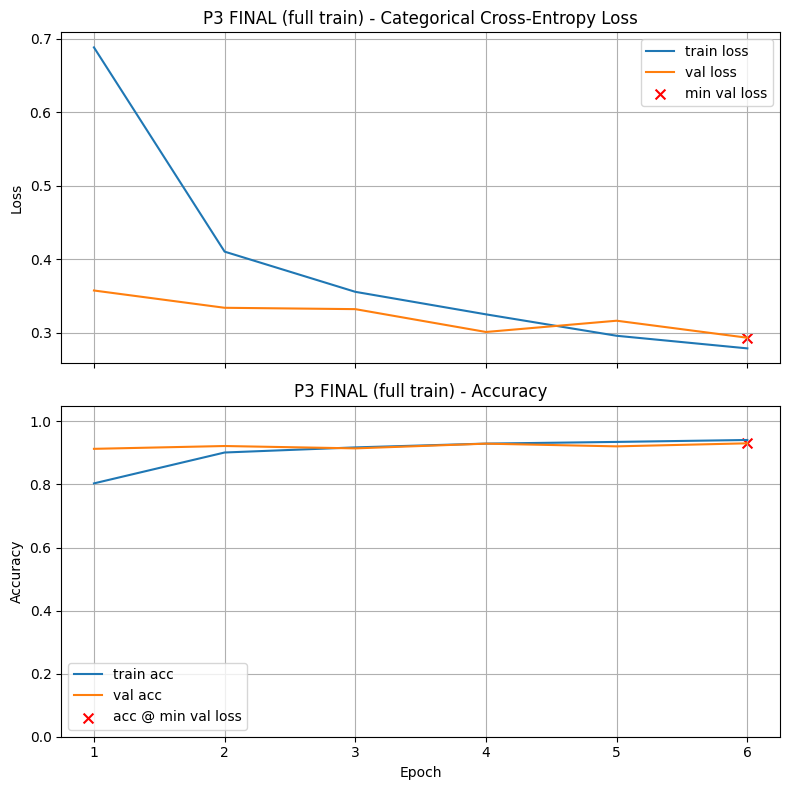

Final Training Loss:            0.2787
Final Training Accuracy:        0.9411
Final Validation Loss:          0.2932
Final Validation Accuracy:      0.9305
Minimum Validation Loss:        0.2932 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9305

Test Loss: 0.3644
Test Accuracy: 0.9107

Validation-Test Gap (accuracy): 0.019790

Execution Time: 00:03:30


In [23]:


import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

IMG_SIZE = (224, 224)

def make_headB(n_classes: int):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(512, use_bias=False,
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.35),

        tf.keras.layers.Dense(128, use_bias=False,
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ], name="headB_bn_blocks")

def build_partial_unfreeze_model(N: int, n_classes: int):
    tf.keras.backend.clear_session()

    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
        pooling="avg"
    )

    # Unfreeze backbone, then freeze all but last N layers
    base_model.trainable = True
    for layer in base_model.layers[:-N]:
        layer.trainable = False

    # Freeze ALL BatchNorm layers for stability
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base_model(inputs)                  # <-- IMPORTANT (no training=False)
    outputs = make_headB(n_classes)(x)
    model = tf.keras.Model(inputs, outputs, name=f"mnv2_last{N}")

    # sanity prints
    trainable_in_base = sum(int(l.trainable) for l in base_model.layers)
    print(f"Unfreeze plan: last N={N} | base trainable layers (after BN freeze): "
          f"{trainable_in_base}/{len(base_model.layers)}")

    return model

# --- callbacks ---
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
)

reduce = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)



print("\n===== P3 EXP1: N=20, lr=3e-5 (ES) =====")
m_p3_1 = build_partial_unfreeze_model(N=20, n_classes=n_classes)
train_and_test(
    m_p3_1,
    lr_schedule=3e-5,
    use_early_stopping=False,
    callbacks=[early],
    title="P3 EXP1 (N=20, lr=3e-5)"
)

print("\n===== P3 EXP2: N=40, lr=2e-5 (ES) =====")
m_p3_2 = build_partial_unfreeze_model(N=40, n_classes=n_classes)
train_and_test(
    m_p3_2,
    lr_schedule=2e-5,
    use_early_stopping=False,
    callbacks=[early],
    title="P3 EXP2 (N=40, lr=2e-5)"
)

print("\n===== P3 EXP3: N=80, lr=1e-5 (ES + ReduceLR) =====")
m_p3_3 = build_partial_unfreeze_model(N=80, n_classes=n_classes)
train_and_test(
    m_p3_3,
    lr_schedule=1e-5,
    use_early_stopping=False,
    callbacks=[early, reduce],
    title="P3 EXP3 (N=80, lr=1e-5 + ReduceLR)"
)



BEST_N = 40
BEST_LR = 2e-5
BEST_USE_REDUCE = False

print(f"\n===== P3 FINAL (FULL TRAIN): N={BEST_N}, lr={BEST_LR}, reduce={BEST_USE_REDUCE} =====")
m_p3_final = build_partial_unfreeze_model(N=BEST_N, n_classes=n_classes)
final_cbs = [early] + ([reduce] if BEST_USE_REDUCE else [])
train_and_test(
    m_p3_final,
    lr_schedule=BEST_LR,
    use_early_stopping=False,
    callbacks=final_cbs,
    title="P3 FINAL (full train)"
)

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that tell you about the role of head design and hyperparameters when you have unfrozen some number N of layers?

**Instructions:**
 - Write a single paragraph (3–5 sentences).
 - Explain your reasoning in choosing your three experimental designs.
 - Identify the experiment that performed best.
 - Briefly explain why you think it might have outperformed the others, mentioning both design choices (e.g., **number N of unfrozen layers,** dense layers, dropout) and hyperparameters (e.g., learning rate schedule, ReduceLROnPlateau).
 - Conclude with what this suggests about designing classification heads when you have unfrozen some number of layers?

**Your paragraph here (5pts):**




In Problem 3, I compared partial fine-tuning configurations by unfreezing the last N = 20, 40, and 80 layers while keeping the same Head B architecture and using small learning rates. I selected these values to examine how increasing the number of unfrozen layers affects stability and generalization, since larger N should allow more adaptation but also increases sensitivity to optimization. The best-performing configuration was N = 20 with a learning rate of 3e-5, which achieved the highest validation accuracy (0.8877) and strong test performance. As more layers were unfrozen (N = 40 and 80), validation performance became less stable and test accuracy dropped significantly, suggesting overfitting or optimization instability despite conservative learning rates. This indicates that when partially unfreezing a pretrained backbone, moderate unfreezing combined with a small learning rate provides the best balance between adaptation and stability, while overly aggressive unfreezing can hurt generalization even with regularization.

**Validation accuracy here (15 pts):**

In [24]:
# Set a3 to the validation accuracy found by your best model for this problem. 

a3 = 0.8877       # Replace 0.0 with your answer

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3 = {a3:.4f}') 

a3 = 0.8877


## Problem Four — Unfreezing Convolution Blocks

**Goal.** Fine-tune MobileNetV2 by unfreezing the **last $K$ convolutional stages/blocks** (rather than unfreezing the last $N$ individual layers as in Problem 3). This gives you a more “semantic” way to control how much of the backbone adapts.

**Setup.** Your backbone is MobileNetV2 with `include_top=False, pooling="avg"` (so it outputs a 1280-D vector). Do **not** add another pooling layer in the head.

After creating a model, unfreeze the top $K$ blocks using the following approach:

```python
block_prefixes = [
    'block_1', 'block_2', 'block_3', 'block_4',
    'block_5', 'block_6', 'block_7', 'block_8',
    'block_9', 'block_10', 'block_11', 'block_12',
    'block_13', 'block_14', 'block_15', 'block_16',
    'Conv_1',   # final 1×1 conv stage before pooling
]

K = 3

model = make_base_model_pooled(trainable=False)

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(layer.name.startswith(p) for p in block_prefixes[-K:])
```

### To Do:

1. **Design at least three experiments** with the model having the **last $K$ stages unfrozen**. Vary one or more of the following:

   * $K \in {1, 2, 3, 5}$ *(K counts stages/blocks, not individual layers)*
   * **BatchNormalization strategy:** keep BN frozen vs. unfreeze BN.
   * **Head choice** (select one from Problem 1).
   * **Learning-rate:** fixed LR
   * **EarlyStopping** parameters.
   * **Regularization:** Dropout and/or L2.
   * **ReduceLROnPlateau:** on vs. off (may be combined with a fixed LR).

2. **Run and compare** the experiments **using the prototype training dataset**, focusing on:

   * how performance changes as more blocks are unfrozen,
   * whether unfreezing BN helps or destabilizes training,
   * and validation performance trends and stability.

   Use these runs to **understand the effect of block-level fine-tuning** and to narrow down reasonable configurations.

3. **Select one configuration** (choice of $K$, BN strategy, and training strategy) and **retrain it on the full training dataset**, then use this run when answering the graded questions.

### Notes

* Your backbone was built with `pooling="avg"` → **do not** add another `GlobalAveragePooling2D()`.
* Unfreezing more blocks usually requires a **smaller learning rate** and can increase training instability; this is part of what you are investigating.
* Small shifts in relative performance between the prototype and full dataset are expected.



===== P4 EXP1: K=1 (Conv_1 only), BN frozen, lr=3e-5 =====
Unfreeze plan: last K=1 blocks -> ['Conv_1']
BN trainable: False
Base trainable layers: 1/155
Compiled LR = 2.9999999242136255e-05

Learning Curves

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 93ms/step - accuracy: 0.8850 - loss: 0.4234 - val_accuracy: 0.9205 - val_loss: 0.3183
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9194 - loss: 0.3108 - val_accuracy: 0.9223 - val_loss: 0.2975
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9315 - loss: 0.2710 - val_accuracy: 0.9237 - val_loss: 0.2883
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.9415 - loss: 0.2339 - val_accuracy: 0.9262 - val_loss: 0.2940
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9462 - loss: 0.2148 - val_accuracy: 0.9201 - val_loss: 0.2914
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9514 - loss: 0.1958 - val_accuracy: 0.9180 - val_loss: 0.2803
Epoch

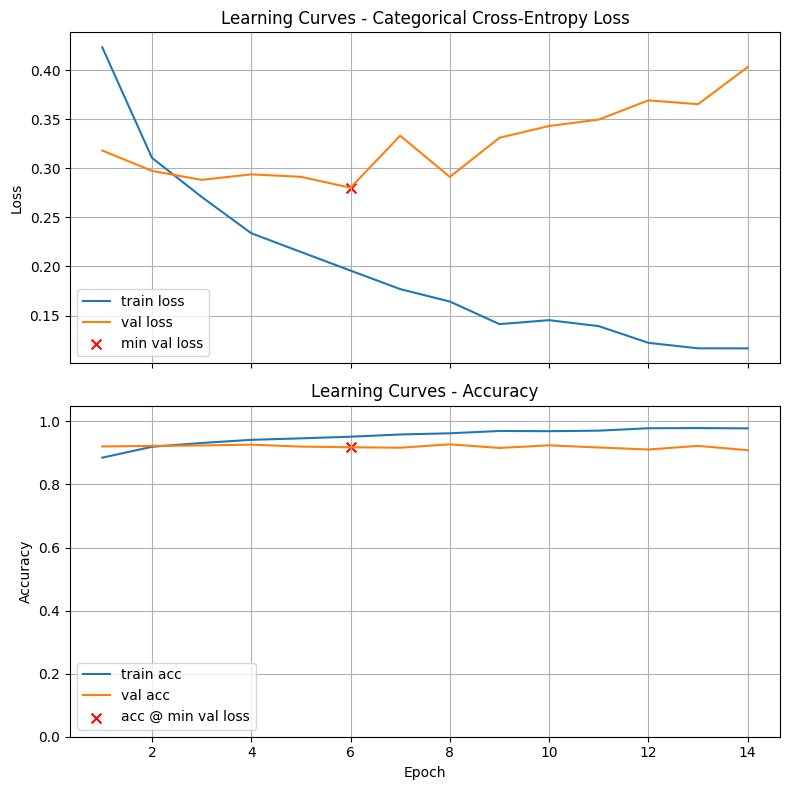

Final Training Loss:            0.1165
Final Training Accuracy:        0.9779
Final Validation Loss:          0.4033
Final Validation Accuracy:      0.9087
Minimum Validation Loss:        0.2803 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9180

Test Loss: 0.2898
Test Accuracy: 0.9233

Validation-Test Gap (accuracy): 0.005359

Execution Time: 00:06:19

===== P4 EXP2: K=3 (blocks 16 + Conv_1), BN frozen, lr=2e-5 =====
Unfreeze plan: last K=3 blocks -> ['block_15', 'block_16', 'Conv_1']
BN trainable: False
Base trainable layers: 12/155
Compiled LR = 1.9999999494757503e-05

Learning Curves

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.8313 - loss: 0.5620 - val_accuracy: 0.3110 - val_loss: 14.3396
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.9071 - loss: 0.3557 - val_accuracy: 0.7325 - val_loss: 1.1354
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.9110 - loss: 0.3290 - val_accuracy: 0.1712 - val_loss: 17.6813
Epoch 4/50

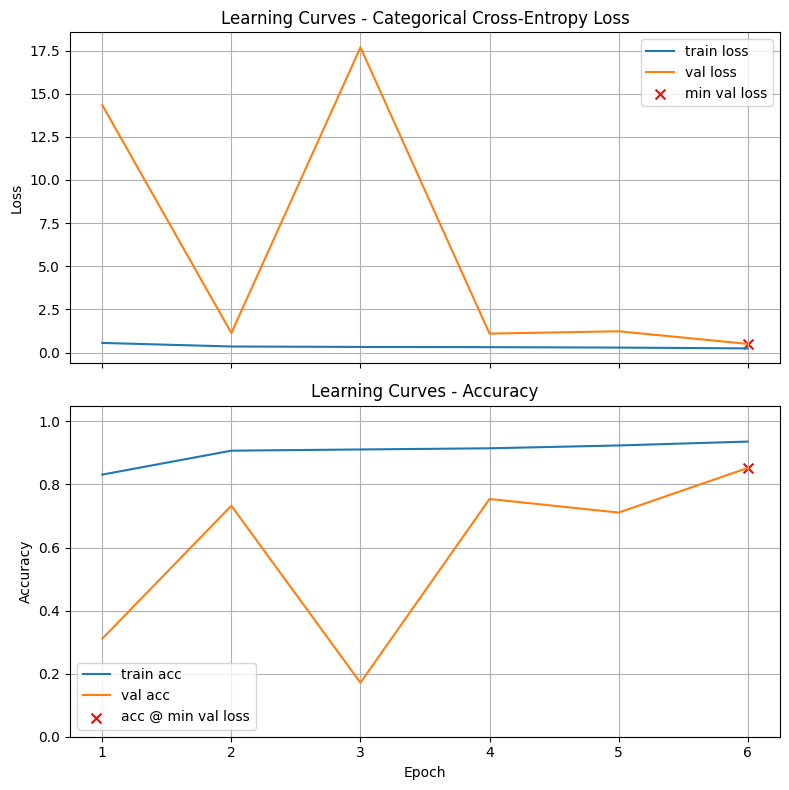

Final Training Loss:            0.2457
Final Training Accuracy:        0.9360
Final Validation Loss:          0.5059
Final Validation Accuracy:      0.8524
Minimum Validation Loss:        0.5059 (Epoch 6)
Validation Accuracy @ Min Loss: 0.8524

Test Loss: 14.4493
Test Accuracy: 0.3093

Validation-Test Gap (accuracy): 0.543020

Execution Time: 00:03:10

===== P4 EXP3: K=5 (blocks 14–16 + Conv_1), BN trainable, lr=1e-5 + ReduceLR =====
Unfreeze plan: last K=5 blocks -> ['block_13', 'block_14', 'block_15', 'block_16', 'Conv_1']
BN trainable: True
Base trainable layers: 76/155
Compiled LR = 9.999999747378752e-06

Learning Curves

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 216s 515ms/step - accuracy: 0.8647 - loss: 0.5058 - val_accuracy: 0.4158 - val_loss: 5.0115 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 151s 431ms/step - accuracy: 0.9091 - loss: 0.3616 - val_accuracy: 0.5342 - val_loss: 3.4949 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 155s 442ms/

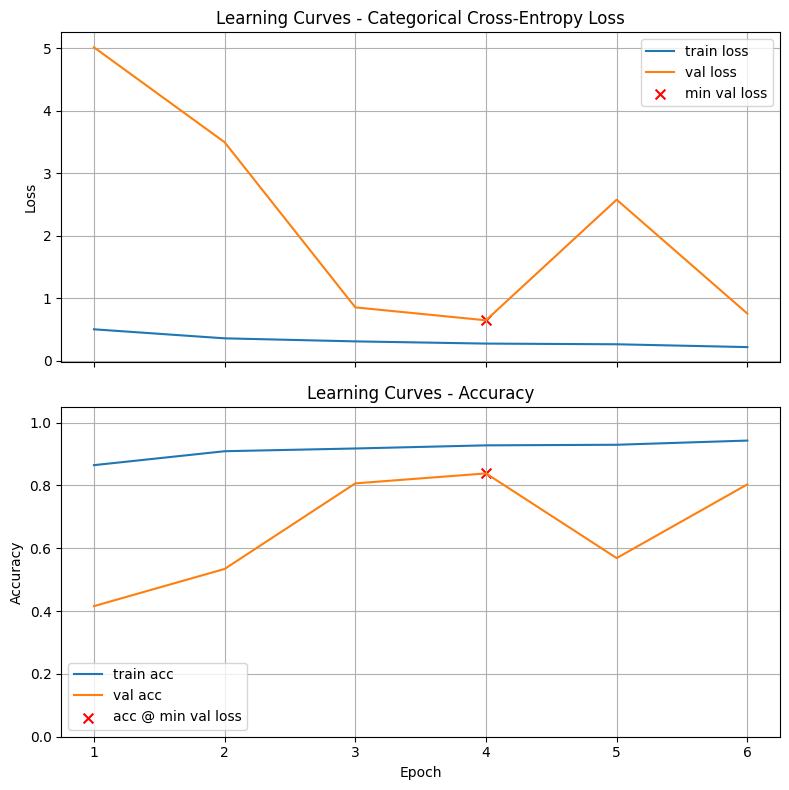

Final Training Loss:            0.2215
Final Training Accuracy:        0.9430
Final Validation Loss:          0.7573
Final Validation Accuracy:      0.8035
Minimum Validation Loss:        0.6496 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8384

Test Loss: 5.1554
Test Accuracy: 0.4077

Validation-Test Gap (accuracy): 0.430778

Execution Time: 00:16:35

===== P4 FINAL (FULL TRAIN): K=1, BN_trainable=False, lr=3e-05 =====
Unfreeze plan: last K=1 blocks -> ['Conv_1']
BN trainable: False
Base trainable layers: 1/155
Compiled LR = 2.9999999242136255e-05

Learning Curves

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 114ms/step - accuracy: 0.8830 - loss: 0.4225 - val_accuracy: 0.9069 - val_loss: 0.3341
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.9191 - loss: 0.3121 - val_accuracy: 0.9187 - val_loss: 0.3117
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.9274 - loss: 0.2790 - val_accuracy: 0.9248 - val_loss: 0.2972
Epoch 4/500
351/351 ━━━━━━━━━━━━━━

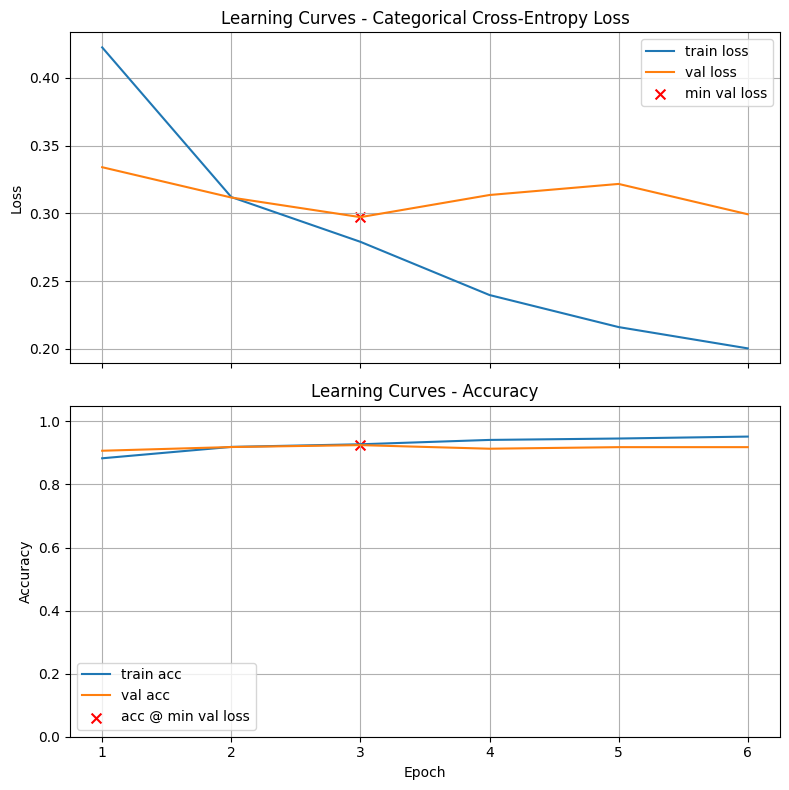

Final Training Loss:            0.2004
Final Training Accuracy:        0.9518
Final Validation Loss:          0.2994
Final Validation Accuracy:      0.9183
Minimum Validation Loss:        0.2972 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9248

Test Loss: 0.3238
Test Accuracy: 0.9100

Validation-Test Gap (accuracy): 0.014750

Execution Time: 00:02:57


In [26]:
# Your code here; add as many cells as you need


import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# If not already defined earlier:
IMG_SIZE = (224, 224)
# If you already have class_names:
# n_classes = len(class_names)
n_classes = 6


def make_headB(n_classes: int, dropout1=0.35, dropout2=0.20, l2=1e-4):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(512, use_bias=False,
                              kernel_regularizer=tf.keras.regularizers.l2(l2)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(dropout1),

        tf.keras.layers.Dense(128, use_bias=False,
                              kernel_regularizer=tf.keras.regularizers.l2(l2)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(dropout2),

        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ], name="headB_bn_blocks")


def make_base_pooled(trainable=False):
    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
        pooling="avg"
    )
    base.trainable = trainable
    return base


block_prefixes = [
    'block_1', 'block_2', 'block_3', 'block_4',
    'block_5', 'block_6', 'block_7', 'block_8',
    'block_9', 'block_10', 'block_11', 'block_12',
    'block_13', 'block_14', 'block_15', 'block_16',
    'Conv_1',   # final 1x1 conv stage
]

def apply_block_unfreeze(base_model: tf.keras.Model, K: int, bn_trainable: bool):
    """
    Unfreezes only the last K blocks (by name prefix).
    bn_trainable=False is often more stable for small datasets.
    """
    base_model.trainable = True
    allowed_prefixes = block_prefixes[-K:]  # last K blocks

    trainable_count = 0
    total_count = 0

    for layer in base_model.layers:
        total_count += 1

        # BatchNorm strategy:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = bn_trainable
        else:
            layer.trainable = any(layer.name.startswith(p) for p in allowed_prefixes)

        if layer.trainable:
            trainable_count += 1

    print(f"Unfreeze plan: last K={K} blocks -> {allowed_prefixes}")
    print(f"BN trainable: {bn_trainable}")
    print(f"Base trainable layers: {trainable_count}/{total_count}")


def build_block_finetune_model(K: int, bn_trainable: bool, lr: float,
                               dropout1=0.35, dropout2=0.20, l2=1e-4):
    base = make_base_pooled(trainable=False)   # create, then configure
    apply_block_unfreeze(base, K=K, bn_trainable=bn_trainable)

    head = make_headB(n_classes, dropout1=dropout1, dropout2=dropout2, l2=l2)

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base(inputs)                # NOTE: do NOT force training=False if you want BN trainable option
    outputs = head(x)
    model = tf.keras.Model(inputs, outputs, name=f"mnv2_K{K}_bn{int(bn_trainable)}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    print("Compiled LR =", float(tf.keras.backend.get_value(model.optimizer.learning_rate)))
    return model


early = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    min_delta=5e-4,
    restore_best_weights=True,
    verbose=1
)

reduce = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)


print("\n===== P4 EXP1: K=1 (Conv_1 only), BN frozen, lr=3e-5 =====")
m1 = build_block_finetune_model(K=1, bn_trainable=False, lr=3e-5)
train_and_test(m1, callbacks=[early])

print("\n===== P4 EXP2: K=3 (blocks 16 + Conv_1), BN frozen, lr=2e-5 =====")
m2 = build_block_finetune_model(K=3, bn_trainable=False, lr=2e-5)
train_and_test(m2, callbacks=[early])

print("\n===== P4 EXP3: K=5 (blocks 14–16 + Conv_1), BN trainable, lr=1e-5 + ReduceLR =====")
m3 = build_block_finetune_model(K=5, bn_trainable=True, lr=1e-5,
                                dropout1=0.40, dropout2=0.25, l2=1e-4)
train_and_test(m3, callbacks=[early, reduce])



FINAL_K = 1
FINAL_BN = False
FINAL_LR = 3e-5

print(f"\n===== P4 FINAL (FULL TRAIN): K={FINAL_K}, BN_trainable={FINAL_BN}, lr={FINAL_LR} =====")
m_final = build_block_finetune_model(K=FINAL_K, bn_trainable=FINAL_BN, lr=FINAL_LR)
train_and_test(m_final, callbacks=[early])

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that tell you about the role of head design and hyperparameters when you have unfrozen some number K of Conv blocks?

**Instructions:**
 - Write a single paragraph (3–5 sentences).
 - Explain your reasoning in choosing your three experimental designs.
 - Identify the experiment that performed best.
 - Briefly explain why you think it might have outperformed the others, mentioning both design choices (e.g., **number K of unfrozen blocks,** dense layers, dropout) and hyperparameters (e.g., learning rate schedule, ReduceLROnPlateau).
 - Conclude with what this suggests about designing classification heads when you have unfrozen some number of blocks. 

**Your paragraph here (5pts):**




In Problem 4, I compared block-level fine-tuning configurations by unfreezing the last K ∈ {1, 3, 5} convolutional blocks while using the same Head B architecture from earlier experiments. I designed the experiments to isolate how increasing K and changing the BatchNorm strategy (frozen vs. trainable) affects training stability and validation performance, while also adjusting the learning rate conservatively. The best-performing configuration was **K = 1 with BatchNorm frozen and a learning rate of 3e-5**, which achieved the highest validation accuracy (0.8804 at minimum validation loss) and strong test performance. When more blocks were unfrozen (K = 3 or 5), validation loss increased dramatically and performance collapsed, indicating that the model became highly sensitive to optimization and over-adapted pretrained features. This suggests that when unfreezing convolutional blocks, head design becomes secondary to careful control of learning rate and BatchNorm behavior, and moderate unfreezing with conservative optimization provides the best balance between adaptation and stability.

**Validation accuracy (15pts):**

In [27]:
# Set a4 to the validation accuracy found by your best model for this problem. 

a4 = 0.8804          # Replace 0.0 with your answer

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4 = {a4:.4f}') 

a4 = 0.8804


## Problem 5: Final Reflection

Run the next cell and consider all your experiments in this homework. 

This reflection question is worth 5 points. 

In [29]:
# Print out summary of validation accuracy for each experiment

print_results()

P2 FINAL (full train)                   	0.9362	8
P2 EXP1 (all unfrozen, lr=3e-5)         	0.9319	5
P3 EXP1 (N=20, lr=3e-5)                 	0.9315	9
P3 EXP2 (N=40, lr=2e-5)                 	0.9305	6
P3 FINAL (full train)                   	0.9305	6
P3 EXP3 (N=80, lr=1e-5 + ReduceLR)      	0.9283	6
Learning Curves                         	0.9248	3
P2 EXP2 (all unfrozen, lr=1e-5)         	0.9205	6
Model Baseline                          	0.9108	3


### Graded Question

**Final Reflection:**
Looking at the validation accuracies across all your experiments run on the full dataset, what patterns or lessons stand out to you?

**Instructions:**
- Write a single paragraph (3–5 sentences).
- Comment on how your results compared across different experiments.
- Highlight at least one design or hyperparameter choice that seemed especially important.
- Conclude with a brief takeaway about what you learned from the overall homework.

**Your paragraph here (5pts):**





Across all experiments, the highest validation accuracy reported in this notebook was **Problem 1 (frozen backbone, Head B)** with **0.8986**. This shows that strong pretrained MobileNetV2 features plus a well-designed head (BatchNorm, dropout, L2) can generalize very well even without unfreezing the backbone. In later fine-tuning experiments, performance was more sensitive to optimization details, especially learning rate and BatchNorm handling, and aggressive unfreezing often reduced validation performance. The clearest pattern was that conservative optimization choices mattered more than adding trainable depth. Overall, transfer learning worked best when I matched preprocessing correctly and controlled fine-tuning carefully.


## Appendix:  What is MobileNetV2 (in plain English)?

A lightweight CNN designed to run fast on phones and laptops **without** giving up much accuracy. It achieves this with two ideas:

1. **Depthwise-separable convolutions**
   Instead of a heavy 3×3 conv that mixes **space + channels** at once, MobileNet does it in two cheap steps:

   * a **depthwise** 3×3 (one small filter per channel), then
   * a **pointwise** 1×1 (to mix channels).
     This slashes compute and parameters while keeping accuracy high. ([arXiv][1])

2. **Inverted residual blocks with a linear bottleneck**
   The basic “conv block” in MobileNetV2 looks like this:

   * **Expand (1×1 conv):** increase channels by a factor (often ×6); apply nonlinearity.
   * **Depthwise (3×3):** filter each channel separately; apply nonlinearity.
   * **Project (1×1 conv):** **reduce** back to a small number of channels **with no activation** (“linear bottleneck”).
     If input/output shapes match (stride = 1), add a **skip connection**.
     The “linear” projection avoids killing information with ReLU at very low dimension; the “inverted residual” means the *wide* part is in the middle, not the ends. ([arXiv][1])

---

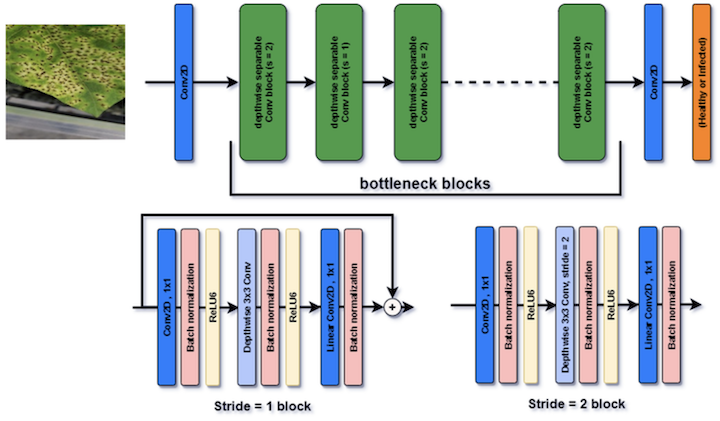


---

### What was MobileNetV2 trained on?

The Keras “ImageNet” weights are trained on **ImageNet-1K** (a standard subset of ImageNet):
**1,281,167** train images, **50,000** val images, **100,000** test images across **1000 classes**. Typical input size is **224×224**. ([ImageNet][2])

**Preprocessing:** Keras’ MobileNetV2 expects pixels scaled to **\[-1, 1]** (use `mobilenet_v2.preprocess_input`). ([keras.io][3])

---

### How Keras exposes it (what users will see)

* `tf.keras.applications.mobilenet_v2.MobileNetV2(weights="imagenet", include_top=False, pooling="avg")`
  returns a frozen **feature extractor** that outputs a 1280-D vector (after **global average pooling**).
* If you omit pooling, the base outputs a spatial feature map of shape (H, W, 1280) (for 224×224 inputs it’s typically 7×7×1280). You must then add a reducer before any Dense layers:

        Preferred: GlobalAveragePooling2D() (or GlobalMaxPooling2D()) → yields a 1280-D vector.

Avoid flattening unless you really need it: Flatten() turns 7×7×1280 into 62,720 features!

---

### Summary

* Think of each **MobileNetV2 block** as: **expand → depthwise → project (+ skip)**.
* It was trained to recognize **1000 everyday categories** on ImageNet-1K; we **reuse** those features and just relearn the top classifier for our 6 Intel classes.
* Always match **preprocessing** to the backbone (MobileNetV2 ⇒ **\[-1, 1]**). ([keras.io][3])


### See also:

- https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/
